In [1]:
from pathlib import Path
from PIL import Image
import numpy as np
import torch
import torchvision
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
content = Path('landscape.jpg')
style = Path('style.jpg')

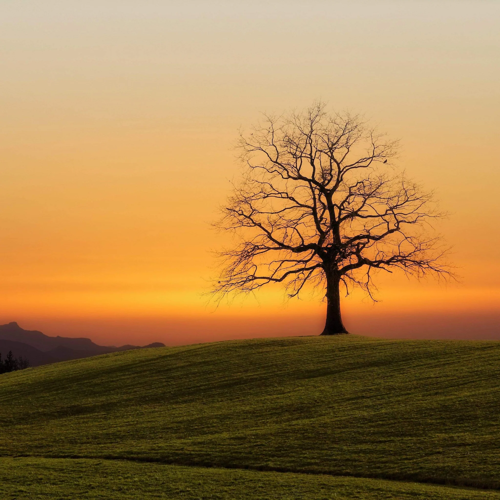

In [3]:
with Image.open(content) as img:
  display(img.resize((500,500)))

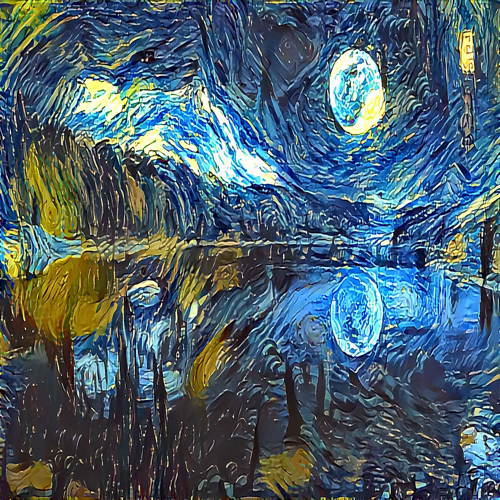

In [4]:
with Image.open(style) as img:
  display(img.resize((500,500)))

In [5]:
model = torchvision.models.vgg19(weights = torchvision.models.VGG19_Weights.DEFAULT).to(device)
print(model)

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:05<00:00, 101MB/s]


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

In [6]:
for params in model.features.parameters():
  params.requires_grad_(False)

# Simply setting the model to evaluation model will still track and store gradients but not update(slowing down training)

In [7]:
print('Total Parameters ',sum([p.numel() for p in model.parameters()]))

Total Parameters  143667240


In [8]:
# Data Preprocessing
with Image.open(content) as img:
  data = np.array(img.resize((512,512)))
  data = torch.from_numpy(data)
  data = data.permute(2,0,1)/255
  data = (data - torch.tensor([0.485, 0.456, 0.406]).view(3,1,1))/torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
  data = data.unsqueeze(0).to(device) # Adding batch dimension at axis 0
  print('Content ',data.shape)

with Image.open(style) as img:
  style_data = np.array(img.resize((512,512)))
  style_data = torch.from_numpy(style_data)
  style_data = style_data.permute(2,0,1)/255.0
  style_data = (style_data - torch.tensor([0.485, 0.456, 0.406]).view(3,1,1))/torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
  style_data = style_data.unsqueeze(0).to(device)
  print('Style ',style_data.shape)

print('Content image gradient tracking ',data.requires_grad)
print('Style image gradient tracking ',style_data.requires_grad)

Content  torch.Size([1, 3, 512, 512])
Style  torch.Size([1, 3, 512, 512])
Content image gradient tracking  False
Style image gradient tracking  False


In [9]:
def extraction(dat,indices=[]):

  s = []

  for count,layer in enumerate(model.features):
    dat = layer(dat)
    if count in indices:
      s.append(dat)
      if max(indices) == count:
        return s

In [10]:
feature_content = extraction(data,[21])
print(feature_content[0].shape)
style_features = extraction(style_data,[0,5,10,19,28])
print(len(style_features))

torch.Size([1, 512, 64, 64])
5


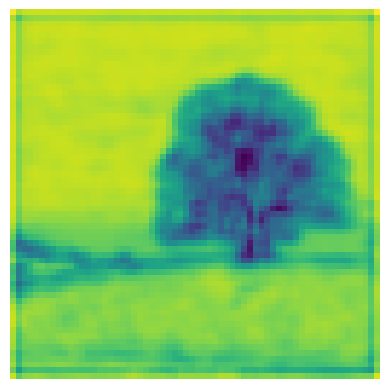

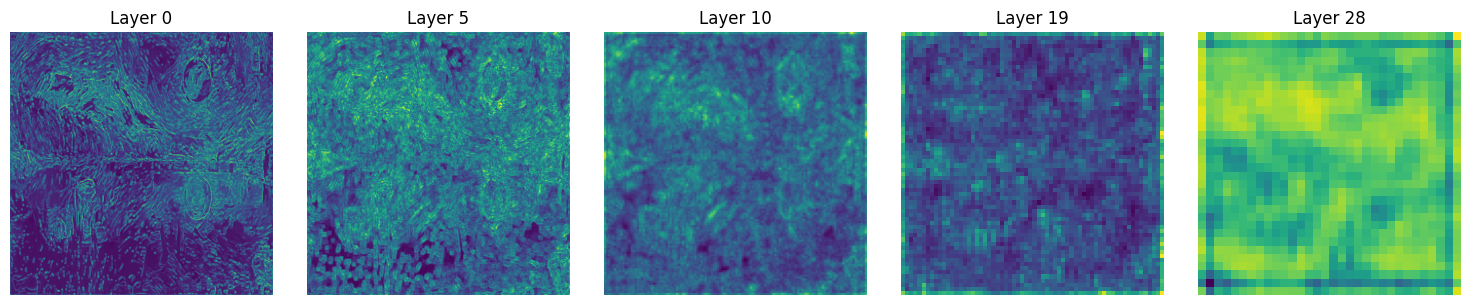

In [11]:
heatmap = feature_content[0].squeeze(0).mean(dim=0).detach().cpu()

plt.imshow(heatmap, cmap='viridis')
plt.axis('off')

fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i in range(5):

    heatmap = style_features[i].squeeze(0).mean(dim = 0).detach().cpu()

    axes[i].imshow(heatmap, cmap='viridis')
    axes[i].axis('off')
    axes[i].set_title(f"Layer {[0,5,10,19,28][i]}")

plt.tight_layout()

In [12]:
def gram_matrix(image):
  c,h,w = image[0].shape
  image = image.squeeze(0).view(c,-1) # shape: (c,h*w)
  gram_matrix = torch.matmul(image,image.T).to(device) # shape : (c,c) pairwise inner products of different channels(features)
  return gram_matrix

In [42]:
style_gram = [gram_matrix(i) for i in style_features]
#target = data.clone().requires_grad_(True)

target = torch.rand(1, 3, 512, 512, device='cuda').requires_grad_(True)


In [43]:
optimizer = torch.optim.Adam([target],lr=0.075)
loss = torch.nn.functional.mse_loss

In [44]:
def training(epochs,content_weight,style_weight):
  style_checkpoints = [0,5,10,19,28]
  content_checkpoint = [21]
  content_history = []
  style_history = []
  total_history = []

  for i in range(epochs):

    target_style = []
    content_features = None
    style_loss = 0


    optimizer.zero_grad()
    x = target # pointer x points towards memory(target)

# we want target to change only by gradient descent(not by convolutions)-> x occupies separate memory but gradients still flow to target,if we don't use x , target will change by forward pass(without gradient descent) only and will feed that distorted target back in 2nd epoch

    for count,layer in enumerate(model.features):

      x = layer(x) # pointer x points towards a new memory block(having layer(x)) hence target don't get changed

      if count in content_checkpoint:
        content_features = x
      if count in style_checkpoints:
        target_style.append(x)
      if count>28:
        break

    content_loss = loss(feature_content[0],content_features)

    live_gram = [gram_matrix(i) for i in target_style]

    for j in range(len(style_gram)):
      style_loss += loss(style_gram[j],live_gram[j])

    total_loss = content_weight * content_loss + style_weight * style_loss

    content_history.append(content_loss.item())
    style_history.append(style_loss.item()*1e-8)
    total_history.append(total_loss.item()*1e-2)
    if (i + 1)%100 == 0:
      print(f'Epoch : {i+1} Style Loss : {style_loss.item()} Content Loss : {content_loss.item()} Total Loss : {total_loss.item()}')
    total_loss.backward()
    optimizer.step()

  return target,content_history,style_history,total_history

In [45]:
target,content_history,style_history,total_history = training(epochs=700,content_weight=200,style_weight = 1e-8)

Epoch : 100 Style Loss : 9600913408.0 Content Loss : 67.98533630371094 Total Loss : 13693.076171875
Epoch : 200 Style Loss : 4867406848.0 Content Loss : 67.8250503540039 Total Loss : 13613.68359375
Epoch : 300 Style Loss : 3790121472.0 Content Loss : 67.77432250976562 Total Loss : 13592.765625
Epoch : 400 Style Loss : 3282921216.0 Content Loss : 67.7490234375 Total Loss : 13582.6337890625
Epoch : 500 Style Loss : 2969623040.0 Content Loss : 67.73406982421875 Total Loss : 13576.5107421875
Epoch : 600 Style Loss : 2771316480.0 Content Loss : 67.72163391113281 Total Loss : 13572.0400390625
Epoch : 700 Style Loss : 2624260096.0 Content Loss : 67.71310424804688 Total Loss : 13568.86328125


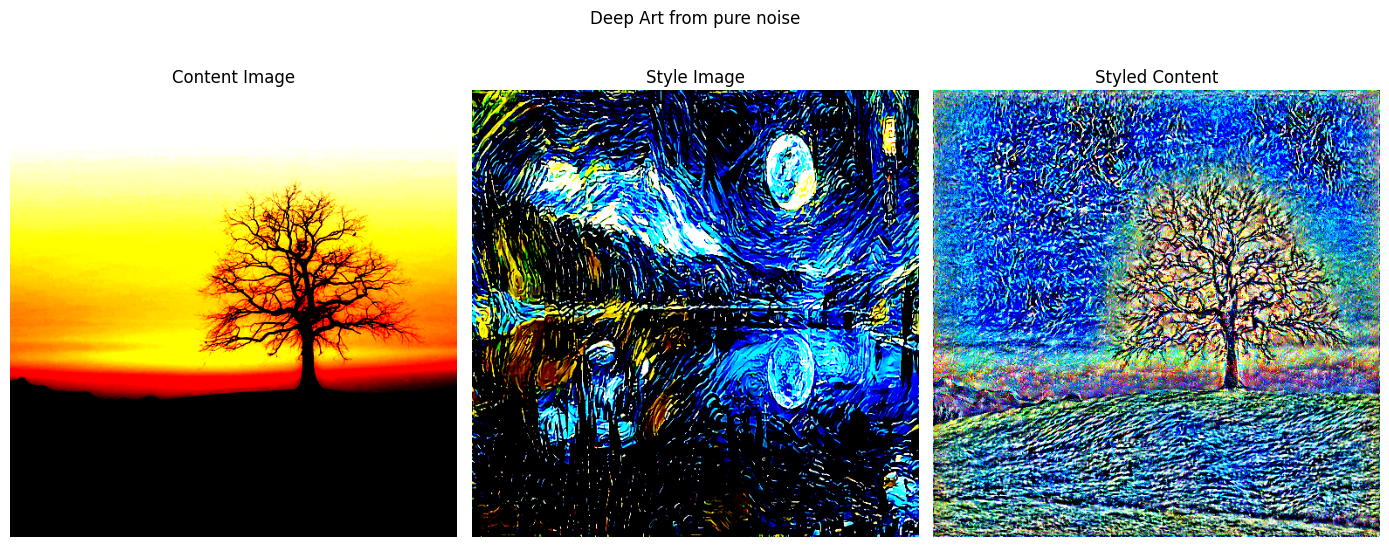

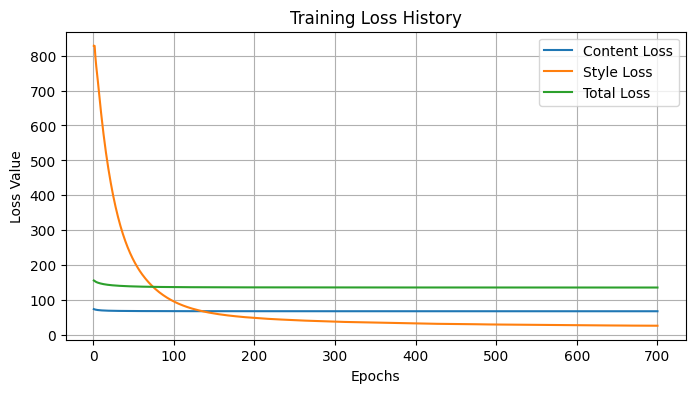

In [46]:
def show_image(tar):
    tar = tar.squeeze(0)
    tar = torch.clamp(tar, 0, 1) # Keeps pixels safely in visible range
    fig,axes = plt.subplots(1,3,figsize=(14,6))
    axes[0].imshow(torch.clamp(data,0,1).squeeze(0).permute(1,2,0).detach().cpu().numpy())
    axes[0].axis('off')
    axes[0].set_title('Content Image')
    axes[1].imshow(torch.clamp(style_data,0,1).squeeze(0).permute(1,2,0).detach().cpu().numpy())
    axes[1].axis('off')
    axes[1].set_title('Style Image')
    axes[2].imshow(tar.detach().cpu().permute(1, 2, 0).numpy())
    axes[2].axis('off')
    axes[2].set_title('Styled Content')
    plt.suptitle("Deep Art from pure noise")
    plt.tight_layout()
    plt.show()

def show_losses(conte, styl, total):
    plt.figure(figsize=(8, 4))
    plt.plot([i for i in range(1,701)],conte, label="Content Loss")
    plt.plot([i for i in range(1,701)],styl, label="Style Loss")
    plt.plot([i for i in range(1,701)],total, label="Total Loss")
    plt.legend()
    plt.xlabel("Epochs")
    plt.ylabel("Loss Value")
    plt.grid()
    plt.title("Training Loss History")
    plt.show()

show_image(target)
show_losses(content_history, style_history, total_history)